##### **<u>SHAP (SHAPLEY ADDITIVE EXPLANATIONS)</u>**

<p>SHAP, or  is a powerful framework designed to help us interpret and explain the predictions made by ml models. SHAP reveils what is inside the black box.</p>

When to use SHAP? 
- Complex ML and DL methods.

For 'simpler' models: overkill

###### Useful links...

https://xai-tutorials.readthedocs.io/en/latest/_xai/importance.html

Boston Housing Price

In [14]:
%pip install shap 

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [15]:
import pandas as pd 
import numpy as np
import xgboost as xgb 
import shap 
from sklearn.model_selection import train_test_split 
from sklearn.datasets import fetch_california_housing

In [4]:
# California Housing Prices
dataset = fetch_california_housing(as_frame=True)
X = dataset['data']
Y = dataset['target']

In [8]:
# Split the data into train and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=0)

# Train an XG boost model
model = xgb.XGBRegressor(objectives='reg:squarederror', random_state=0)
model.fit(X_train, Y_train)

/home/sething2002/.local/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [15:19:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "objectives" } are not used.

  warnings.warn(smsg, UserWarning)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, objectives='reg:squarederror', ...)

In [9]:
### Explain prediction with SHAP values 
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

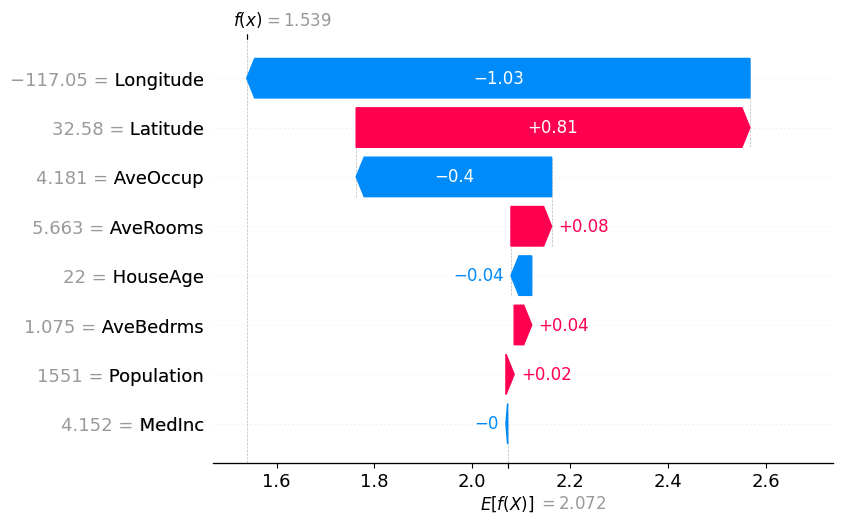

In [10]:
# Visualize the SHAP values for a specific instance 
# shap.summary_plot(shap_values, X_test)
shap.plots.waterfall(shap_values[0]) # waterfall plot for a specific datapoint

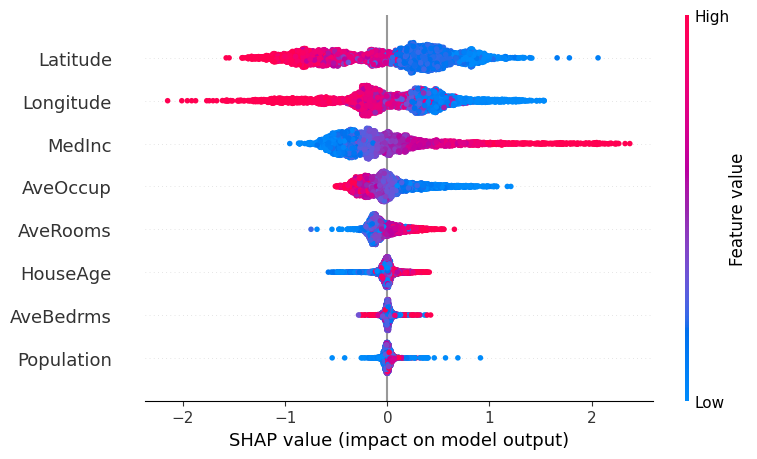

In [11]:
# Plots for all data points
shap.summary_plot(shap_values, X_test)

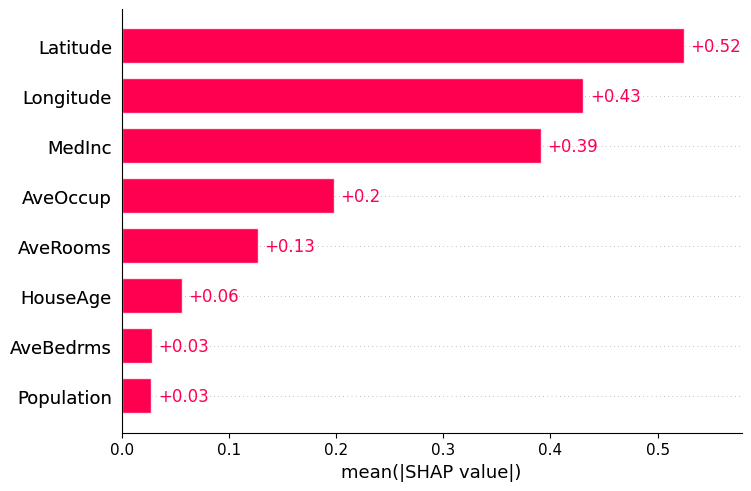

In [12]:
shap.plots.bar(shap_values)

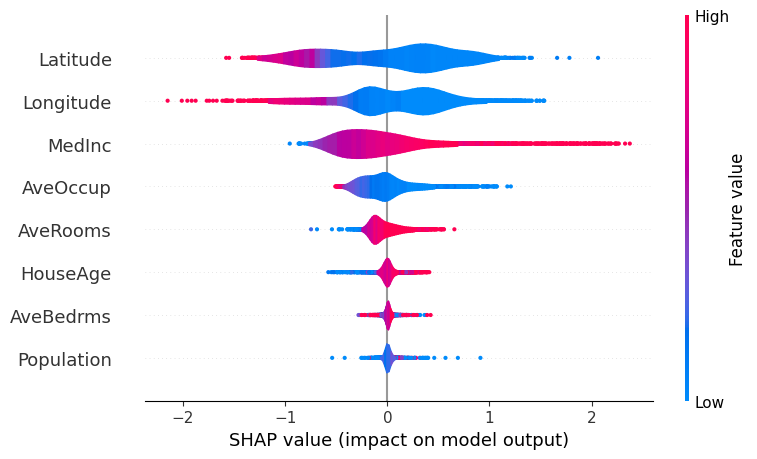

In [13]:
shap.summary_plot(shap_values, plot_type='violin')